## Car Price Prediction Model: Code Explanation

This notebook walks through the process of building a machine learning model to predict car selling prices based on various features. We'll cover data loading, preprocessing, feature engineering, and model training/evaluation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 1: Accessing Data from Google Drive

First, we mount Google Drive to access the `car price prediction.zip` file, which contains our dataset. This allows the notebook to read files stored in your Drive.

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/codealpha tasks/car price prediction.zip'
extraction_path = './car_price_prediction_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"File unzipped to: {extraction_path}")

# List the contents of the extracted directory to see what's inside
print("Contents of extracted directory:")
for root, dirs, files in os.walk(extraction_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

File unzipped to: ./car_price_prediction_data
Contents of extracted directory:
./car_price_prediction_data/car_prediction_data.csv


### Step 2: Unzipping and Loading the Dataset

Next, the zipped file is extracted, and the `car_prediction_data.csv` file is loaded into a pandas DataFrame. We then display the first few rows and a summary of the data to get an initial understanding of its structure and contents, including column names, non-null counts, and data types.

In [ ]:
import pandas as pd

data_path = './car_price_prediction_data/car_prediction_data.csv'
car_data = pd.read_csv(data_path)

print("Data loaded successfully. Here are the first 5 rows:")
print(car_data.head())

print("\nAnd here is some basic info about the dataset:")
car_data.info()

Data loaded successfully. Here are the first 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

And here is some basic info about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year     

In [ ]:
print("\nDescriptive statistics for numerical columns:")
print(car_data.describe())

print("\nUnique values in categorical columns:")
for column in car_data.select_dtypes(include='object').columns:
    print(f"{column}: {car_data[column].nunique()} unique values")
    if car_data[column].nunique() < 20: # Display unique values if there aren't too many
        print(car_data[column].value_counts())



Descriptive statistics for numerical columns:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000

Unique values in categorical columns:
Car_Name: 98 unique values
Fuel_Type: 3 unique values
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type: 2 unique values
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: i

### Step 3: Initial Data Exploration

Here, we perform a more in-depth exploration of the dataset:

*   **Descriptive Statistics:** We calculate and display descriptive statistics (e.g., mean, std, min, max) for numerical columns to understand their distribution.
*   **Unique Values for Categorical Columns:** We identify and display the number of unique values for each categorical column. For columns with fewer than 20 unique values, we also show their value counts to understand their distribution. This helps in identifying columns that might need special handling, like 'Car_Name' with 98 unique values.

In [ ]:
# Add 'Age' column based on current year (assuming 2024 as current year)
car_data['Age'] = 2024 - car_data['Year']

# Drop the original 'Year' column and 'Car_Name' as it has too many unique values
car_data.drop(['Year', 'Car_Name'], axis=1, inplace=True)

# Convert categorical columns to 'category' dtype
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    car_data[col] = car_data[col].astype('category')

print("Data after feature engineering and type conversion:")
print(car_data.head())
print("\nUpdated DataFrame Info:")
car_data.info()

Data after feature engineering and type conversion:
   Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type  \
0           3.35           5.59       27000    Petrol      Dealer   
1           4.75           9.54       43000    Diesel      Dealer   
2           7.25           9.85        6900    Petrol      Dealer   
3           2.85           4.15        5200    Petrol      Dealer   
4           4.60           6.87       42450    Diesel      Dealer   

  Transmission Owner  Age  
0       Manual     0   10  
1       Manual     0   11  
2       Manual     0    7  
3       Manual     0   13  
4       Manual     0   10  

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Selling_Price  301 non-null    float64 
 1   Present_Price  301 non-null    float64 
 2   Kms_Driven     301 non-null    int64   
 3   Fuel_T

### Step 4: Feature Engineering and Data Type Conversion

This crucial step prepares our data for the machine learning model:

*   **Create 'Age' Feature:** A new feature, 'Age' of the car, is calculated by subtracting the 'Year' of manufacturing from the current year (2024). This is often more informative than the 'Year' itself.
*   **Drop Original Columns:** The original 'Year' column is dropped because 'Age' now represents this information. 'Car_Name' is also dropped due to its high cardinality (too many unique values), which would make one-hot encoding inefficient and potentially problematic for the model.
*   **Convert to Category Type:** Several columns (`Fuel_Type`, `Seller_Type`, `Transmission`, `Owner`) are explicitly converted to the 'category' data type. This is a best practice for pandas when dealing with categorical data, optimizing memory usage and signaling to libraries like `get_dummies` how to handle them.

In [ ]:
# Apply one-hot encoding to categorical features
car_data_encoded = pd.get_dummies(car_data, columns=['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'], drop_first=True)

print("Data after one-hot encoding:")
print(car_data_encoded.head())
print("\nUpdated DataFrame Info after encoding:")
car_data_encoded.info()

Data after one-hot encoding:
   Selling_Price  Present_Price  Kms_Driven  Age  Fuel_Type_Diesel  \
0           3.35           5.59       27000   10             False   
1           4.75           9.54       43000   11              True   
2           7.25           9.85        6900    7             False   
3           2.85           4.15        5200   13             False   
4           4.60           6.87       42450   10              True   

   Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  Owner_1  \
0              True                   False                 True    False   
1             False                   False                 True    False   
2              True                   False                 True    False   
3              True                   False                 True    False   
4             False                   False                 True    False   

   Owner_3  
0    False  
1    False  
2    False  
3    False  
4    False  

Updated 

### Step 5: One-Hot Encoding Categorical Features

Machine learning models typically require numerical input. Here, we convert our categorical features into a numerical format using one-hot encoding:

*   **`pd.get_dummies()`:** This function creates new binary (0 or 1) columns for each unique category within the specified categorical features. For example, 'Fuel_Type' with 'Petrol', 'Diesel', and 'CNG' will be converted into 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', and 'Fuel_Type_CNG' (if `drop_first=False`).
*   **`drop_first=True`:** This argument is used to avoid multicollinearity. For each original categorical column, it drops the first category's dummy variable. For instance, if a car is neither 'Diesel' nor 'Petrol', it implicitly means it's 'CNG' (assuming only these three options exist). This reduces redundancy and can help model stability.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = car_data_encoded.drop('Selling_Price', axis=1)
y = car_data_encoded['Selling_Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (240, 9)
Shape of X_test: (61, 9)
Shape of y_train: (240,)
Shape of y_test: (61,)


### Step 6: Splitting Data into Training and Testing Sets

Before training, the data is split into features (X) and the target variable (y). The target variable `Selling_Price` is what our model will predict. The features are all other columns. Then, the dataset is divided into training and testing sets:

*   **`X` (Features):** Contains all the independent variables that will be used to make predictions.
*   **`y` (Target):** Contains the dependent variable, `Selling_Price`.
*   **`train_test_split`:** This function divides the data into:
    *   `X_train`, `y_train`: Used to train the model (80% of the data).
    *   `X_test`, `y_test`: Used to evaluate the model's performance on unseen data (20% of the data).
*   **`random_state=42`:** Ensures reproducibility of the split.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize the Random Forest Regressor model
# You might want to tune hyperparameters for better performance in a real scenario
model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Training Complete.")
print(f"R-squared Score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.3f}")

Model Training Complete.
R-squared Score: 0.962
Mean Absolute Error: 0.617


### Step 7: Model Training and Evaluation (Random Forest Regressor)

In this final step, we train our machine learning model and assess its performance:

*   **`RandomForestRegressor`:** This is an ensemble learning method that fits multiple decision tree regressors on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. It's a robust choice for regression tasks.
*   **`model.fit(X_train, y_train)`:** The model learns the patterns from the training data.
*   **`model.predict(X_test)`:** The trained model makes predictions on the unseen test data.
*   **Model Evaluation:**
    *   **R-squared Score (`r2_score`):** Measures the proportion of the variance in the dependent variable that is predictable from the independent variables. An R-squared of 0.962 means that 96.2% of the variance in `Selling_Price` can be explained by our model's features.
    *   **Mean Absolute Error (`mean_absolute_error`):** Measures the average magnitude of the errors in a set of predictions, without considering their direction. An MAE of 0.617 means, on average, our model's predictions are off by approximately 0.617 units of `Selling_Price` (which are in Lakhs INR).

### Step 8: Data Visualization

Now, let's create some visualizations to better understand the data distribution and relationships between variables. This will help in identifying potential patterns or anomalies.

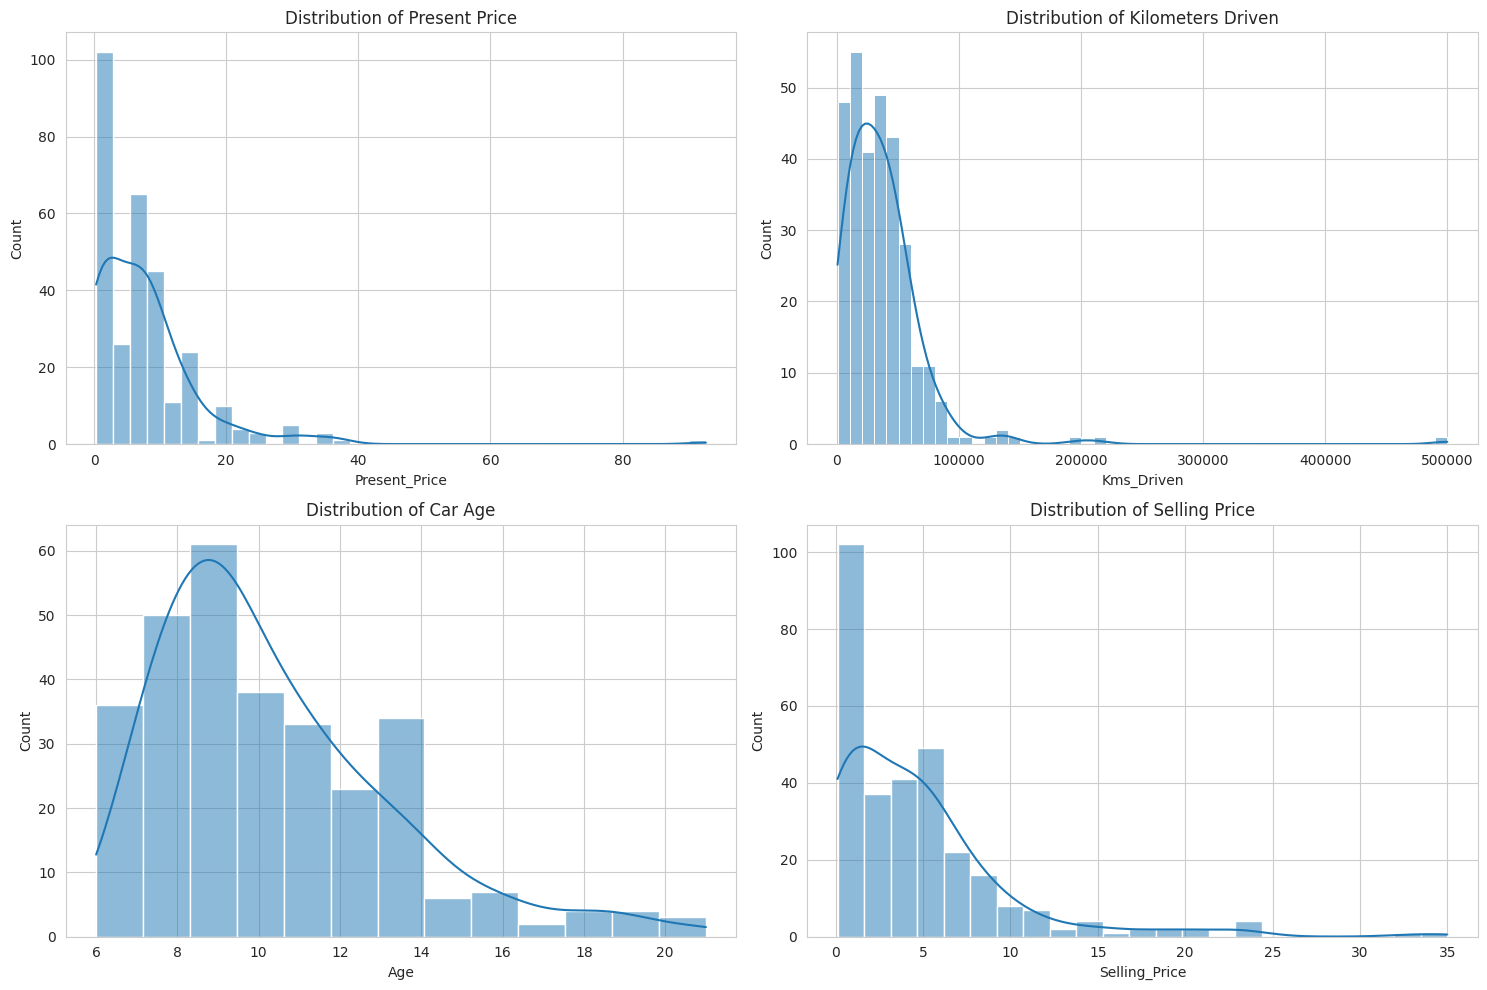

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Histograms for numerical features
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(car_data_encoded['Present_Price'], kde=True)
plt.title('Distribution of Present Price')

plt.subplot(2, 2, 2)
sns.histplot(car_data_encoded['Kms_Driven'], kde=True)
plt.title('Distribution of Kilometers Driven')

plt.subplot(2, 2, 3)
sns.histplot(car_data_encoded['Age'], kde=True)
plt.title('Distribution of Car Age')

plt.subplot(2, 2, 4)
sns.histplot(car_data_encoded['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')

plt.tight_layout()
plt.show()

These histograms show the distribution of our key numerical features. We can observe:

*   **Present_Price:** Appears to be right-skewed, with most cars having a lower present price.
*   **Kms_Driven:** Also right-skewed, indicating many cars have driven fewer kilometers, but some have very high mileage.
*   **Age:** Shows a distribution towards older cars in the dataset.
*   **Selling_Price:** Similar to present price, it is right-skewed, suggesting most cars are sold for lower prices.

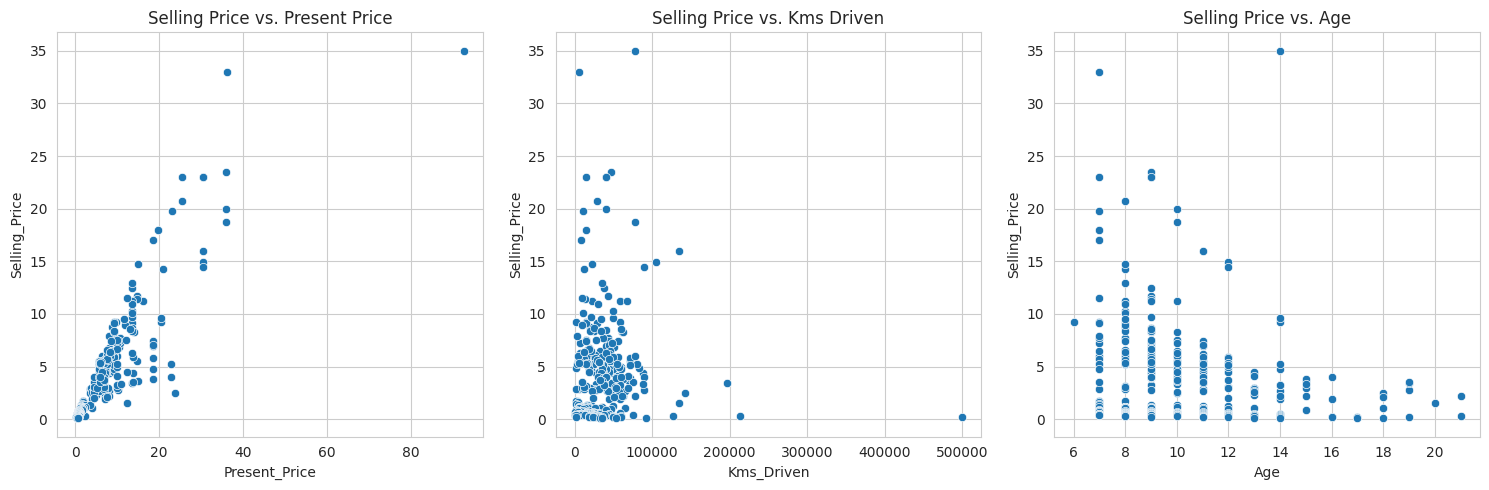

In [ ]:
# Scatter plots for numerical features vs. Selling Price
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Present_Price', y='Selling_Price', data=car_data_encoded)
plt.title('Selling Price vs. Present Price')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=car_data_encoded)
plt.title('Selling Price vs. Kms Driven')

plt.subplot(1, 3, 3)
sns.scatterplot(x='Age', y='Selling_Price', data=car_data_encoded)
plt.title('Selling Price vs. Age')

plt.tight_layout()
plt.show()

From the scatter plots, we can infer:

*   **Selling Price vs. Present Price:** There's a strong positive correlation, meaning cars with higher present prices tend to have higher selling prices.
*   **Selling Price vs. Kms Driven:** A weak negative correlation is observed; higher mileage cars tend to have slightly lower selling prices, but it's not a very strong relationship.
*   **Selling Price vs. Age:** A moderate negative correlation, indicating that older cars generally sell for less.

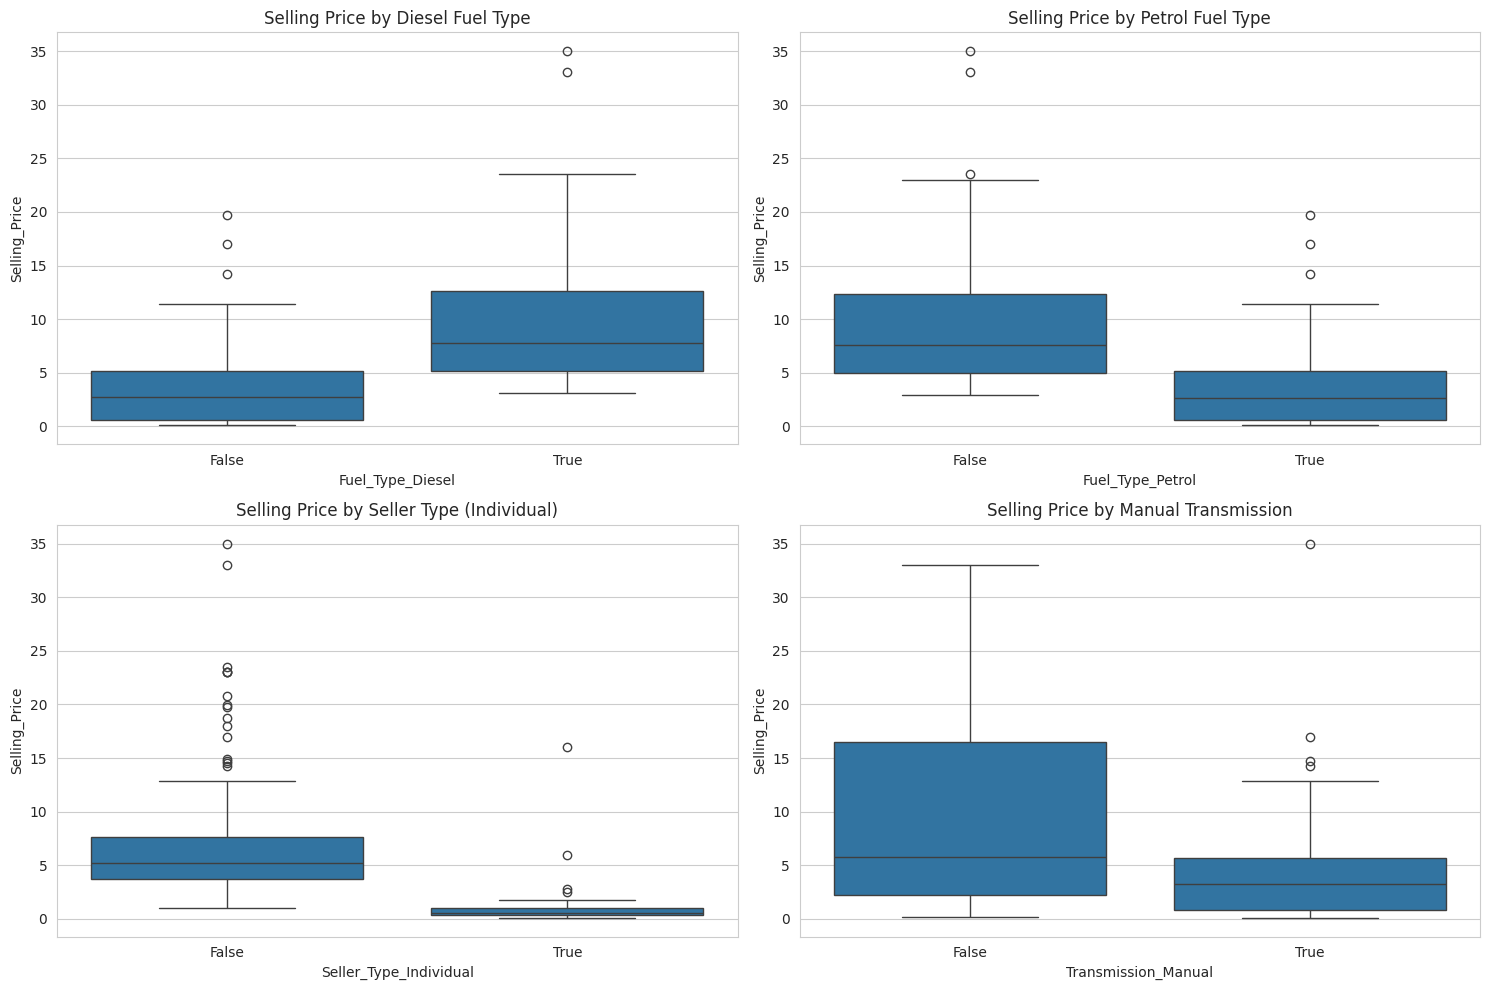

In [ ]:
# Box plots for encoded categorical features vs. Selling Price
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='Fuel_Type_Diesel', y='Selling_Price', data=car_data_encoded)
plt.title('Selling Price by Diesel Fuel Type')

plt.subplot(2, 2, 2)
sns.boxplot(x='Fuel_Type_Petrol', y='Selling_Price', data=car_data_encoded)
plt.title('Selling Price by Petrol Fuel Type')

plt.subplot(2, 2, 3)
sns.boxplot(x='Seller_Type_Individual', y='Selling_Price', data=car_data_encoded)
plt.title('Selling Price by Seller Type (Individual)')

plt.subplot(2, 2, 4)
sns.boxplot(x='Transmission_Manual', y='Selling_Price', data=car_data_encoded)
plt.title('Selling Price by Manual Transmission')

plt.tight_layout()
plt.show()

These box plots illustrate the distribution of selling prices across different categories of our one-hot encoded features:

*   **Fuel Type (Diesel/Petrol):** There are noticeable differences in selling price distributions between cars with Diesel fuel (True) and those without (False, which would include Petrol/CNG). Similarly for Petrol fuel types.
*   **Seller Type (Individual):** Cars sold by individuals generally have a lower median selling price compared to those sold by dealers.
*   **Transmission (Manual):** Manual transmission cars might show a different selling price distribution compared to automatic cars.